# YOLOv8: imágenes originales y una foto propia

Copia de trabajo de **Visión computacional/Notebooks/13 YOLO ultralytics.ipynb**.
Preparada para Google Colab; **todavía no ejecutada**. El notebook original del repositorio no se modifica.

Primero selecciona **Runtime / Entorno de ejecución → Change runtime type / Cambiar tipo de entorno → T4 GPU**.
Después puedes pulsar **Run all**. Al llegar a la carga de tu foto, selecciona un JPG o PNG y espera a que continúe.

Se conserva el modelo `yolov8n.pt`, el entrenamiento `coco128.yaml` durante **3 épocas**,
la predicción CLI de Zidane y la predicción Python del bus. Las dos nuevas predicciones cambian
únicamente la fuente por la misma foto propia. Las celdas adicionales muestran y guardan evidencias;
no cambian el modelo, los umbrales ni los ajustes de entrenamiento.

Al terminar, descarga este `.ipynb` con sus salidas y el ZIP de evidencias. Toma también capturas
de Colab que muestren las cuatro predicciones y el entrenamiento/GPU. El reporte se completa
después, con las clases y cantidades realmente detectadas.


Tutorial original en ultralytics

https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=bpF9-vS_DAaf


App para anotar/etiquetar imágenes de nuestra propia base de datos:

https://app.roboflow.com/login


## A. Instalar y comprobar GPU

Ejecuta la instalación original y después la comprobación. Esta última detiene la preparación
si no hay GPU: selecciona T4 y vuelve a ejecutar desde arriba.


In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()


Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/235.7 GB disk)


In [2]:
import csv
import hashlib
import json
import platform
import re
import shutil
import uuid
from collections import Counter
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path
from IPython.display import Image as Imagen, display
from PIL import Image as PILImage
import torch

assert torch.cuda.is_available(), 'Selecciona Runtime → Change runtime type → T4 GPU y ejecuta desde arriba.'
ART = Path('/content/evidencias_yolo') / uuid.uuid4().hex[:8]
ART.mkdir(parents=True, exist_ok=True)
RUNS = Path(ultralytics.settings['runs_dir']).resolve()
registro = {}
entorno = {
    'fecha_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(),
    'ultralytics': ultralytics.__version__,
    'pytorch': torch.__version__,
    'gpu': torch.cuda.get_device_name(0),
    'colab_detectado': False,
}
try:
    import google.colab
    entorno['colab_detectado'] = True
except ImportError:
    pass
(ART / 'entorno.json').write_text(json.dumps(entorno, indent=2), encoding='utf-8')
print(json.dumps(entorno, indent=2))
print('Carpeta de evidencias de esta ejecución:', ART)

def snapshot_imagenes():
    return {str(p.resolve()): (p.stat().st_mtime_ns, p.stat().st_size)
            for p in RUNS.rglob('*')
            if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png'}}

def mostrar_archivo(path, titulo):
    print(titulo)
    display(Imagen(filename=str(path), width=900))

def guardar_cli(captura, antes, source_stem, etiqueta, fuente):
    texto = re.sub(r'\x1b\[[0-?]*[ -/]*[@-~]', '', captura.stdout + captura.stderr)
    print(texto)
    (ART / f'{etiqueta}_log.txt').write_text(texto, encoding='utf-8')
    despues = snapshot_imagenes()
    candidatas = [Path(p) for p, stamp in despues.items()
                  if stamp != antes.get(p) and Path(p).stem == source_stem]
    if not candidatas:
        raise RuntimeError('No se encontró una imagen nueva del CLI. Revisa el log anterior y las carpetas de resultados.')
    imagen = max(candidatas, key=lambda p: p.stat().st_mtime_ns)
    destino = ART / f'{etiqueta}{imagen.suffix.lower()}'
    shutil.copy2(imagen, destino)
    # El CLI original no solicita etiquetas en TXT. Conservamos su log real.
    lineas_deteccion = [line for line in texto.splitlines()
                       if re.search(r'\b\d+x\d+\b', line) and 'ms' in line]
    registro[etiqueta] = {
        'fuente': fuente, 'pesos': 'yolov8n.pt preentrenado',
        'carpeta_resultados': str(imagen.parent), 'imagen': destino.name,
        'resumen_cli': lineas_deteccion,
    }
    mostrar_archivo(destino, etiqueta)

def guardar_python(resultados, etiqueta, fuente):
    resultado = resultados[0]
    destino = ART / f'{etiqueta}.jpg'
    resultado.save(filename=str(destino))
    cajas = []
    for caja in resultado.boxes:
        clase = int(caja.cls.item())
        cajas.append({'clase_id': clase, 'clase': resultado.names[clase],
                      'confianza': float(caja.conf.item()),
                      'xyxy': caja.xyxy[0].cpu().tolist()})
    registro[etiqueta] = {
        'fuente': fuente, 'pesos': 'YOLOv8n después del entrenamiento de 3 épocas',
        'checkpoint': str(model.trainer.best if model.trainer.best.exists() else model.trainer.last),
        'carpeta_resultados': str(model.predictor.save_dir),
        'imagen': destino.name, 'numero_cajas': len(cajas),
        'clases': dict(Counter(c['clase'] for c in cajas)), 'cajas': cajas,
    }
    print('Clases y cantidad de cajas:', registro[etiqueta]['clases'])
    print('Total:', len(cajas))
    mostrar_archivo(destino, etiqueta)


{
  "fecha_utc": "2026-09-13T02:03:22.957017+00:00",
  "python": "3.13.15",
  "ultralytics": "8.4.150",
  "pytorch": "2.11.0+cu128",
  "gpu": "Tesla T4",
  "colab_detectado": true
}
Carpeta de evidencias de esta ejecución: /content/evidencias_yolo/32b37f0f


## B. Predicción original por CLI: Zidane

La instrucción `yolo` se conserva. La primera línea (`%%capture`) guarda el log;
la celda siguiente lo imprime y muestra la imagen con cajas. Espera ambas celdas.


In [3]:
antes_cli_original = snapshot_imagenes()


In [4]:
%%capture cli_original --no-display
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'


Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 6.4ms
Speed: 155.1ms preprocess, 6.4ms inference, 38.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict

01_zidane_cli


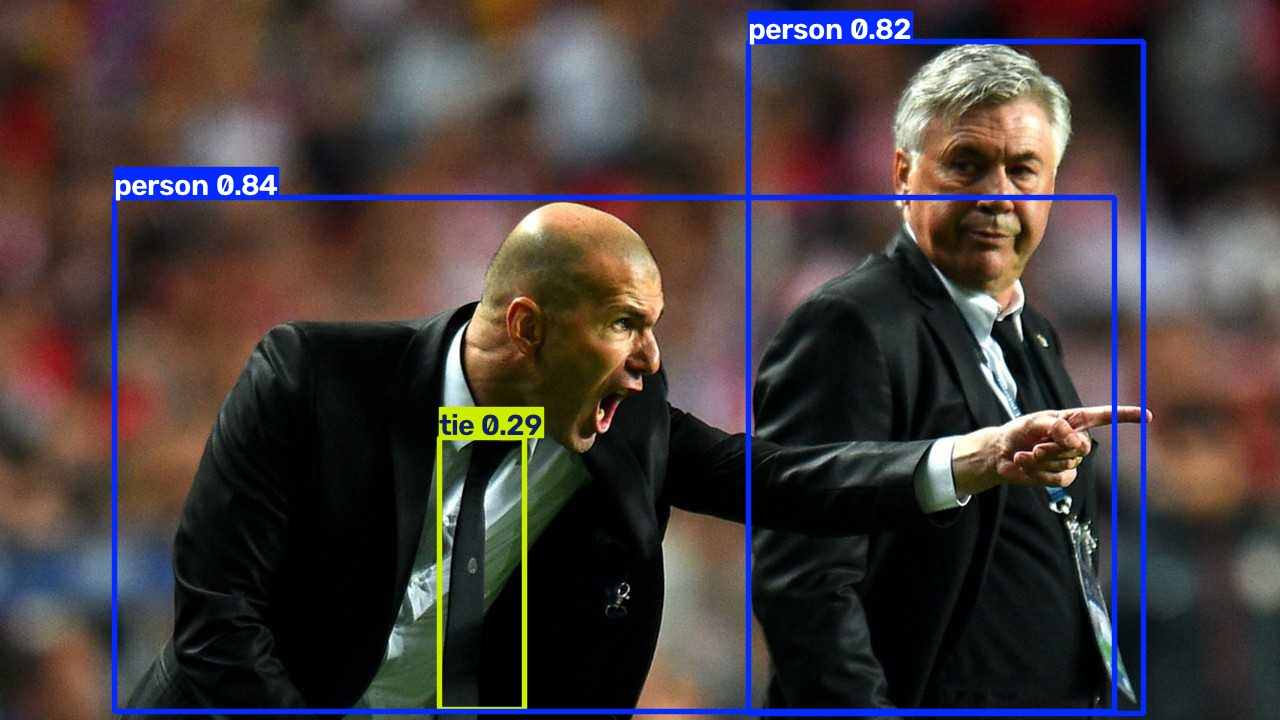

In [5]:
guardar_cli(cli_original, antes_cli_original, 'zidane', '01_zidane_cli',
            'https://ultralytics.com/images/zidane.jpg')


## C. Entrenamiento original y predicción del bus

Se ejecuta el entrenamiento solicitado una sola vez: `coco128.yaml`, `epochs=3`.
Espera a que aparezcan las tres épocas completas y la predicción de `bus.jpg`.
La asignación `resultados_bus = ...` solo conserva el resultado para guardarlo después.


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='coco128.yaml', epochs=3)
resultados_bus = model('https://ultralytics.com/images/bus.jpg', save=True)


Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

Clases y cantidad de cajas: {'bus': 1, 'person': 4, 'stop sign': 1}
Total: 6
02_bus_python


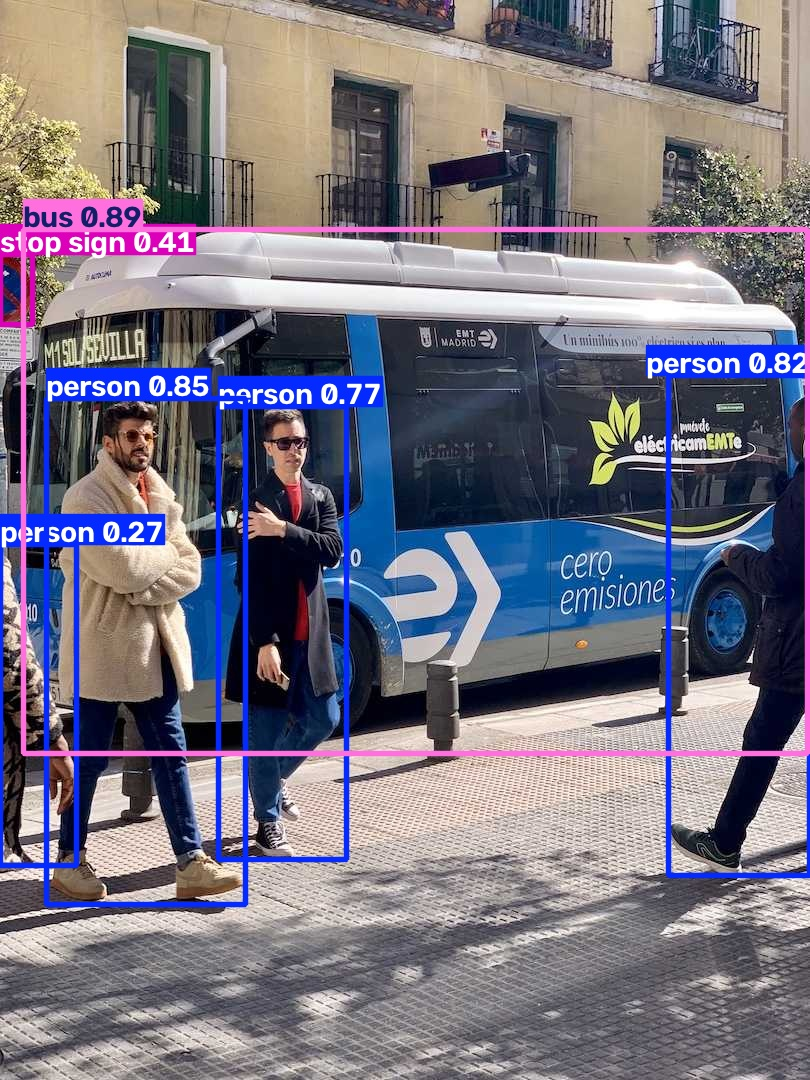

Entrenamiento completado: 3 épocas. Carpeta: /content/runs/detect/train


In [7]:
guardar_python(resultados_bus, '02_bus_python', 'https://ultralytics.com/images/bus.jpg')
carpeta_train = Path(model.trainer.save_dir)
csv_train = carpeta_train / 'results.csv'
with csv_train.open(encoding='utf-8') as f:
    filas_train = list(csv.DictReader(f))
assert len(filas_train) == 3, f'Se esperaban 3 épocas y se encontraron {len(filas_train)}.'
print('Entrenamiento completado: 3 épocas. Carpeta:', carpeta_train)
for nombre in ['results.csv', 'args.yaml', 'results.png']:
    archivo = carpeta_train / nombre
    if archivo.exists():
        shutil.copy2(archivo, ART / ('entrenamiento_' + nombre))
(ART / 'clases_COCO.json').write_text(json.dumps(model.names, indent=2, ensure_ascii=False), encoding='utf-8')
registro['entrenamiento'] = {'modelo_inicial': 'yolov8n.pt', 'dataset': 'coco128.yaml',
                            'epocas_completadas': len(filas_train),
                            'carpeta_resultados': str(carpeta_train),
                            'checkpoint_best': str(model.trainer.best)}


## D. Seleccionar tu foto

Elige **un solo JPG o PNG** con objetos reconocibles: una persona, un perro, una silla,
un auto, una taza o una computadora, por ejemplo. Debe ser una foto diferente de Zidane y del bus.

Al ejecutar la siguiente celda aparece el botón para seleccionar un archivo de tu computadora.
Si pulsaste Run all, selecciona la foto y espera a que continúe. Se guarda una copia con nombre
seguro `mi_foto.jpg` o `mi_foto.png`; sus bytes no cambian. Ambas predicciones usarán exactamente
ese archivo. No se modifica ni reentrena el modelo con tu foto.


Saving feature-highlight-2.png to feature-highlight-2 (1).png
La misma fuente para CLI y Python: /content/mi_foto.png
Foto propia sin detecciones


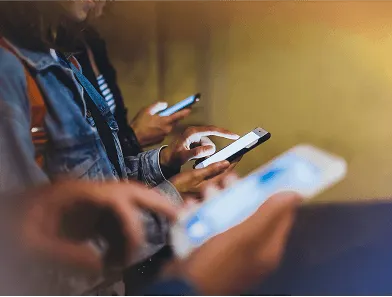

In [10]:
from google.colab import files
subidos = files.upload()
if len(subidos) != 1:
    raise ValueError('Selecciona exactamente una foto JPG o PNG y vuelve a ejecutar esta celda.')
nombre_original, contenido = next(iter(subidos.items()))
with PILImage.open(BytesIO(contenido)) as foto:
    formato = foto.format
    foto.verify()
if formato not in {'JPEG', 'PNG'}:
    raise ValueError('La imagen debe estar en formato JPG o PNG.')
extension = '.jpg' if formato == 'JPEG' else '.png'
MI_FOTO = '/content/mi_foto' + extension
Path(MI_FOTO).write_bytes(contenido)
shutil.copy2(MI_FOTO, ART / ('foto_propia_original' + extension))
sha_foto = hashlib.sha256(contenido).hexdigest()
registro['foto_propia'] = {'nombre_subido': nombre_original, 'archivo_usado': MI_FOTO,
                         'sha256': sha_foto, 'formato': formato,
                         'copia_evidencia': 'foto_propia_original' + extension}
for clave in ['03_foto_propia_cli', '04_foto_propia_python']:
    registro.pop(clave, None)
print('La misma fuente para CLI y Python:', MI_FOTO)
mostrar_archivo(MI_FOTO, 'Foto propia sin detecciones')


## E. Tu foto por CLI: cambiar solo source

Respecto de la celda de Zidane solo cambia `source`. Se mantiene `model=yolov8n.pt` y
no se añade un umbral diferente. `{MI_FOTO}` se sustituye por la ruta del archivo que subiste.


In [11]:
assert hashlib.sha256(Path(MI_FOTO).read_bytes()).hexdigest() == sha_foto
antes_cli_propia = snapshot_imagenes()


In [12]:
%%capture cli_propia --no-display
!yolo predict model=yolov8n.pt source='{MI_FOTO}'


Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/mi_foto.png: 512x640 4 persons, 1 remote, 2 cell phones, 6.9ms
Speed: 34.2ms preprocess, 6.9ms inference, 17.0ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict-3
💡 Learn more at https://docs.ultralytics.com/modes/predict

03_foto_propia_cli


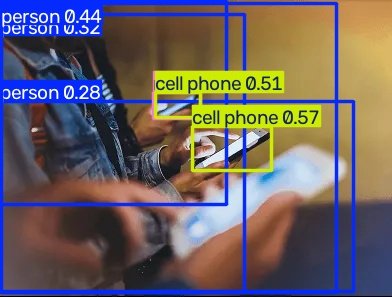

In [13]:
guardar_cli(cli_propia, antes_cli_propia, 'mi_foto', '03_foto_propia_cli', MI_FOTO)


## F. Tu foto por Python: cambiar solo la fuente de model(...)

Usa el mismo objeto `model` con el que predijiste el bus. **No vuelvas a cargar YOLO ni a entrenar.**
El CLI utiliza los pesos originales de `yolov8n.pt`; este objeto Python conserva los pesos
resultantes del entrenamiento. Por eso pueden diferir las cajas y las confianzas: no sería
prueba de que el CLI o Python funcionen incorrectamente.


In [14]:
assert hashlib.sha256(Path(MI_FOTO).read_bytes()).hexdigest() == sha_foto
resultados_mi_foto = model(MI_FOTO, save=True)



image 1/1 /content/mi_foto.png: 512x640 2 persons, 2 remotes, 2 cell phones, 48.4ms
Speed: 1.8ms preprocess, 48.4ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict-2


Clases y cantidad de cajas: {'remote': 2, 'cell phone': 2, 'person': 2}
Total: 6
04_foto_propia_python


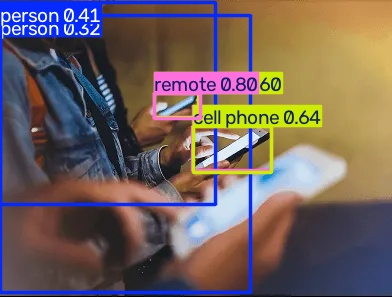

Compara esta imagen con la salida 03_foto_propia_cli.
Nombra las clases concretas, cuenta las cajas y observa si algún objeto visible quedó sin etiqueta.


In [15]:
guardar_python(resultados_mi_foto, '04_foto_propia_python', MI_FOTO)
print('Compara esta imagen con la salida 03_foto_propia_cli.')
print('Nombra las clases concretas, cuenta las cajas y observa si algún objeto visible quedó sin etiqueta.')


## G. Guardar evidencias y descargar

La siguiente celda reúne las cuatro imágenes anotadas, la foto original, los logs del CLI,
las detecciones de Python, el registro del entorno y los resultados del entrenamiento.
No incluye los datasets ni los pesos para mantener el ZIP pequeño.

Además debes guardar:
- Una captura en Colab de Zidane, otra del bus y las dos salidas sobre tu foto, con cajas visibles.
- Una captura de las tres épocas completadas y del entorno con GPU.
- Este notebook **después de ejecutar**, desde Archivo → Descargar → Descargar .ipynb.
- El reporte de media página, completado con lo que realmente detectó el modelo.

Si no hay cajas en tu foto, conserva el resultado y revisa si contiene objetos claros de COCO.
Para probar otra foto, vuelve a ejecutar desde la sección D; no necesitas repetir el entrenamiento.
Si reinicias el entorno, se pierde el modelo en memoria y debes ejecutar de nuevo desde el principio.

Fuentes oficiales: [YOLOv8](https://docs.ultralytics.com/models/yolov8/),
[CLI](https://docs.ultralytics.com/usage/cli/),
[Predicción](https://docs.ultralytics.com/modes/predict/),
[Estado del modelo después de train](https://docs.ultralytics.com/reference/engine/model/).


In [16]:
obligatorias = ['01_zidane_cli', '02_bus_python', '03_foto_propia_cli', '04_foto_propia_python']
assert all(k in registro for k in obligatorias), 'Falta ejecutar alguna de las cuatro predicciones.'
assert registro['entrenamiento']['epocas_completadas'] == 3
assert registro['03_foto_propia_cli']['fuente'] == registro['04_foto_propia_python']['fuente'] == MI_FOTO
(ART / 'resultados_yolo.json').write_text(json.dumps(registro, ensure_ascii=False, indent=2), encoding='utf-8')
print('Evidencias guardadas:')
for p in sorted(ART.iterdir()):
    print(p.name)
from zipfile import ZipFile, ZIP_DEFLATED
archivo_zip = '/content/evidencias_yolo.zip'
archivos = {registro[k]['imagen'] for k in obligatorias}
archivos.update({registro['foto_propia']['copia_evidencia'], 'resultados_yolo.json',
                 'entorno.json', 'clases_COCO.json', '01_zidane_cli_log.txt',
                 '03_foto_propia_cli_log.txt', 'entrenamiento_results.csv',
                 'entrenamiento_args.yaml'})
if (ART / 'entrenamiento_results.png').exists():
    archivos.add('entrenamiento_results.png')
with ZipFile(archivo_zip, 'w', ZIP_DEFLATED) as paquete:
    for nombre in sorted(archivos):
        paquete.write(ART / nombre, nombre)
files.download(archivo_zip)
print('Descarga también el notebook ejecutado y guarda tus capturas de Colab.')


Evidencias guardadas:
01_zidane_cli.jpg
01_zidane_cli_log.txt
02_bus_python.jpg
03_foto_propia_cli.jpg
03_foto_propia_cli_log.txt
04_foto_propia_python.jpg
clases_COCO.json
entorno.json
entrenamiento_args.yaml
entrenamiento_results.csv
entrenamiento_results.png
foto_propia_original.png
resultados_yolo.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga también el notebook ejecutado y guarda tus capturas de Colab.
